# Cancer Subtyping + Aging Pipeline (Full Demonstration)

This notebook runs the current end-to-end computational oncology pipeline:

1. Preprocessing and alignment of transcriptomic and clinical data
2. Variance filtering, Cox feature selection, scaling, and PCA
3. GMM tumor clustering with k selected by silhouette score
4. Pathway enrichment with GSEA
5. Biological process annotation and pathway heatmaps
6. Aging program scoring
7. Survival analysis
8. Visualization and export of results

Each step includes a short explanation to clarify the biological and computational purpose.


In [1]:
# =========================
# PIPELINE PARAMETERS
# =========================

# These values document the current pipeline defaults.
# The implementation lives in the pipeline modules.
K_SEARCH_RANGE = (2, 5)
TOP_VARIANCE_GENES = 5000
TOP_COX_GENES = 500
USE_SURVIVAL = True
RANDOM_STATE = 42
FIGSIZE = (8, 6)


In [2]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd

# Run notebook from the repository root, even when opened from notebooks/.
if Path.cwd().name == "notebooks":
    os.chdir("..")

Path("results/figures").mkdir(parents=True, exist_ok=True)
Path("results/gsea").mkdir(parents=True, exist_ok=True)
Path("results/aging").mkdir(parents=True, exist_ok=True)

print(Path.cwd())


c:\Users\jimad\source\repos\jimadan\cancer-subtyping-ml


In [3]:
from pipelines.preprocessing_pipeline import run_preprocessing
from pipelines.feature_pipeline import run_feature_pipeline
from pipelines.clustering_pipeline import run_clustering_pipeline
from pipelines.gsea_pipeline import run_gsea_pipeline
from pipelines.survival_pipeline import run_survival_pipeline

from analysis.pathway_analysis import build_nes_matrix, build_group_matrix
from analysis.aging_analysis import compute_aging_scores

from plots.plot_gsea import plot_pathway_heatmap, plot_pathway_support_heatmap
from plots.plot_aging import plot_aging_scores, plot_aging_heatmaps


## Step 1 — Preprocessing

We load and clean expression + clinical data, ensuring consistency between samples.

This step removes noise and prepares the dataset for downstream statistical analysis.

In [4]:
expr, clinical = run_preprocessing()

print(expr.shape, clinical.shape)


[INFO] Loading cached preprocessed data...
[INFO] Cached expression shape: (1214, 17675)
[INFO] Cached clinical shape: (1214, 2)
(1214, 17675) (1214, 2)


## Step 2 -> Feature Engineering

The current feature pipeline performs variance filtering, univariate Cox feature selection, expression scaling, and PCA.

This reduces noise while prioritizing genes with potential survival relevance before clustering.


In [5]:
expr_filtered, expr_survival, X_pca = run_feature_pipeline(expr, clinical)


[STEP] Feature filtering...
[INFO] Variance filtering: 17675 -> 17675 genes
[INFO] Top-5000 genes selected

[STEP] Survival feature selection...
[INFO] Cox-selected expression shape: (1214, 500)

[STEP] Scaling...

[STEP] PCA...
[INFO] PCA components: 291


## Step 3 -> Tumor Subtyping (Clustering)

We identify molecular tumor subtypes using GMM clustering in PCA space.

The clustering pipeline tests `k=2..5` and selects the best value using silhouette score. UMAP is computed for visualization only.


In [6]:
X_umap, labels, best_k, model = run_clustering_pipeline(X_pca)

print("Optimal number of clusters:", best_k)


[STEP] UMAP...


c:\Users\jimad\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



[STEP] Clustering (k search 2-5)...
[CLUSTERING] Testing k=2
[CLUSTERING] Testing k=3
[CLUSTERING] Testing k=4
[CLUSTERING] Testing k=5
[INFO] Best k: 2
[INFO] Silhouette: 0.21288688360017813
[INFO] Clustering results: {'method': 'gmm', 'n_clusters': 2, 'silhouette_score': 0.2129, 'davies_bouldin_score': 1.5139, 'bic': 1196725.5, 'aic': 760251.61}
Optimal number of clusters: 2


In [7]:
clusters = pd.DataFrame({
    "sample": expr_filtered.index,
    "cluster": labels
}).set_index("sample")

clusters["cluster"].value_counts()


cluster
0    1080
1     134
Name: count, dtype: int64

## Step 4 -> Pathway Enrichment (GSEA)

We identify biological pathways enriched in each tumor subtype using ranked differential-expression scores.

The current GSEA stage searches Hallmark, KEGG, Reactome, and GO Biological Process gene sets, then annotates results into broad biological process groups.


In [8]:
gsea_df = run_gsea_pipeline(expr_survival, clusters)

[GSEA] cluster 0
[GSEA] cluster 1


In [9]:
nes_matrix = build_nes_matrix(gsea_df)
group_matrix = build_group_matrix(gsea_df)

print("NES matrix shape:", nes_matrix.shape)
print("Biological process group matrix shape:", group_matrix.shape)

if "pathway_group" in gsea_df.columns and not gsea_df.empty:
    display(gsea_df["pathway_group"].value_counts())


NES matrix shape: (29, 2)
Biological process group matrix shape: (5, 2)


pathway_group
other           29
cell_cycle      22
inflammation     2
senescence       2
stemness         2
Name: count, dtype: int64

## Step 5 -> Aging Programs

We compute aging-related pathway scores across tumor subtypes.

The current aging programs are `inflammaging`, `mitochondrial_stress`, `proteostasis_loss`, `cell_cycle_dysregulation`, `identity_drift`, and `dna_damage_response`.


In [10]:
aging_scores = compute_aging_scores(gsea_df)

display(aging_scores)


,cluster,inflammaging,inflammaging_n,mitochondrial_stress,mitochondrial_stress_n,proteostasis_loss,proteostasis_loss_n,cell_cycle_dysregulation,cell_cycle_dysregulation_n,identity_drift,identity_drift_n,dna_damage_response,dna_damage_response_n
0,0,1.662214,1,0,0,0,0,1.756870,4,1.514898,1,1.535953,1
1,1,-1.623480,1,0,0,0,0,-1.735211,4,-1.530876,1,-1.535571,1


## Step 6 — Visualization

We visualize tumor structure, pathway activity, and aging-related biological signals across molecular subtypes.

These plots help interpret the biological differences between tumor groups identified by clustering.

In [11]:
# =========================
# PATHWAY ENRICHMENT HEATMAPS
# =========================

plot_pathway_heatmap(gsea_df)
plot_pathway_support_heatmap(gsea_df)


WindowsPath('results/figures/pathway_support_heatmap.png')

Biological Interpretation -> Pathway Heatmaps

The pathway NES heatmap summarizes pathway activity across tumor subtypes using normalized enrichment scores from GSEA.

The pathway support heatmap shows how many significant entries support each pathway/cluster combination.

Key biological process groups currently used in the project are:

- senescence
- inflammation
- cell_cycle
- metabolism
- stemness
- other

These visualizations help identify subtype-specific programs such as immune activation, proliferation, metabolic rewiring, stress response, differentiation drift, or DNA damage biology.


In [12]:
# =========================
# AGING SIGNATURE SCORES
# =========================

plot_aging_scores(aging_scores)

WindowsPath('results/figures/aging_scores.png')

Biological Interpretation — Aging Score Plot

This plot summarizes aging-related activity across tumor subtypes.

Aging signatures typically include pathways associated with:

cellular senescence
DNA damage accumulation
chronic inflammation
mitochondrial dysfunction
oxidative stress
stemness loss

Higher aging scores may indicate tumors with stronger age-associated molecular phenotypes.

Biologically, this can suggest:

increased genomic instability
altered immune microenvironment
accelerated tissue degeneration
senescence-associated secretory phenotype (SASP) activity

Comparing aging scores across subtypes helps determine whether specific tumor groups are more strongly linked to aging biology.

This is important because aging-associated tumors may exhibit:

distinct progression dynamics
altered treatment response
different survival outcomes

In [13]:
# =========================
# AGING HEATMAPS
# =========================

plot_aging_heatmaps(aging_scores)


WindowsPath('results/figures/aging_heatmaps.png')

Biological Interpretation -> Aging Heatmaps

The aging heatmaps show aging-program activity and the number of contributing pathways for each tumor subtype.

The score panel summarizes weighted NES activity. The support panel shows how many pathways contributed to each program score.

This helps distinguish subtypes dominated by inflammaging, mitochondrial stress, proteostasis loss, cell-cycle dysregulation, identity drift, or DNA damage response.


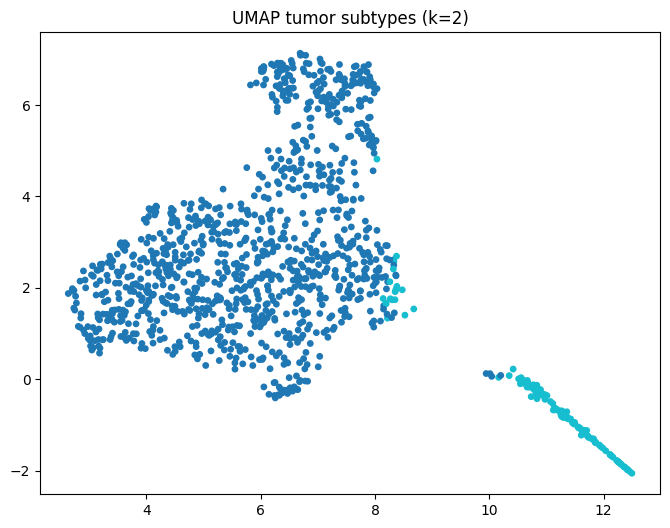

In [14]:
plt.figure(figsize=FIGSIZE)

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=labels,
    cmap="tab10",
    s=15
)

plt.title(f"UMAP tumor subtypes (k={best_k})")
plt.savefig("results/figures/umap.png", dpi=300, bbox_inches="tight")
plt.show()


Biological Interpretation — UMAP Tumor Subtypes

The UMAP projection visualizes similarities between tumor samples in reduced-dimensional space.

Key interpretation:

each point represents one tumor sample
nearby points have similar transcriptomic profiles
separated groups correspond to distinct molecular subtypes

Well-separated clusters suggest strong biological differences between tumors.

These differences may arise from:

different oncogenic drivers
immune composition
metabolic state
differentiation status
aging-associated molecular programs

The UMAP plot provides an intuitive overview of tumor heterogeneity and validates the clustering strategy used for subtype discovery.

## Step 7 — Survival Analysis

We test whether tumor subtypes have different survival outcomes.

In [15]:
if USE_SURVIVAL:
    run_survival_pipeline(clinical, clusters, X_umap, labels)


[STEP] Survival analysis...
[INFO] Log-rank test: {'test_statistic': np.float64(25.984555336863334), 'p_value': np.float64(3.4415966504686616e-07)}
               coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                  
cluster_1  0.824766   2.281347  0.165567        0.500262        1.149271   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                               
cluster_1             1.649153              3.15589     0.0  4.981479   

                      p   -log2(p)  
covariate                           
cluster_1  6.309998e-07  20.595857  
   test_statistic             p   -log2(p)
0       25.984555  3.441597e-07  21.470419


<Figure size 640x480 with 0 Axes>

In [16]:
gsea_df.to_csv("results/gsea/all_gsea_results.csv", index=False)
aging_scores.to_csv("results/aging/aging_scores.csv", index=False)

print("Pipeline completed successfully")


Pipeline completed successfully


## Biological Interpretation

- Tumor samples are clustered into transcriptomic subtypes using GMMs in PCA space.
- GSEA translates subtype-specific gene rankings into pathway biology.
- Biological process groups summarize enriched pathways into senescence, inflammation, cell-cycle, metabolism, stemness, or other categories.
- Aging scores summarize age-associated pathway programs and their pathway support counts.
- Survival analysis tests whether the inferred subtypes have clinical relevance.

Together, these steps connect tumor heterogeneity, pathway biology, aging programs, and patient outcome.
